In [2]:
# ============================================
# LIBRERÍAS REQUERIDAS
# ============================================
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# ============================================
# 1. CARGAR Y PREPARAR DATOS
# ============================================
# Cargar datos enriquecidos de compras con contexto de navegación
df = pd.read_csv("./data/purchases_processed.csv")

# Convertir columnas de fecha a datetime
date_cols = ["event_time", "first_view", "last_view", "first_cart", "last_cart"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True).dt.tz_localize(None)

print(f"\n=== DATASET DE COMPRAS CARGADO ===\n")
print(f"Dimensiones: {df.shape[0]:,} compras x {df.shape[1]} variables")
print(f"\n=== PRIMERAS FILAS ===\n")
print(df.head())


=== DATASET DE COMPRAS CARGADO ===

Dimensiones: 1,659,788 compras x 10 variables

=== PRIMERAS FILAS ===

           event_time    user_id  product_id   price  view_count  cart_count  \
0 2019-11-01 00:00:41  559368633    13200605  566.30           3           0   
1 2019-11-01 00:01:04  513351129     1005161  211.92           2           0   
2 2019-11-01 00:04:51  562958505     1004856  128.42          15           8   
3 2019-11-01 00:05:34  541854711    26401669  109.66           2           0   
4 2019-11-01 00:06:33  557746614     1801881  488.80          22          13   

           first_view           last_view          first_cart  \
0 2019-10-31 23:57:42 2019-11-01 00:01:20                 NaT   
1 2019-11-01 00:00:17 2019-11-01 00:01:57                 NaT   
2 2019-10-22 11:54:57 2019-11-19 08:07:51 2019-11-09 08:39:52   
3 2019-11-01 00:04:55 2019-11-01 00:06:00                 NaT   
4 2019-10-30 13:27:08 2019-11-03 12:16:38 2019-10-31 22:39:19   

            last_car

In [4]:
# Información de estructura
print("\n=== ESTRUCTURA DEL DATASET ===\n")
print(df.info())


=== ESTRUCTURA DEL DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659788 entries, 0 to 1659787
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   event_time  1659788 non-null  datetime64[ns]
 1   user_id     1659788 non-null  int64         
 2   product_id  1659788 non-null  int64         
 3   price       1659788 non-null  float64       
 4   view_count  1659788 non-null  int64         
 5   cart_count  1659788 non-null  int64         
 6   first_view  1656205 non-null  datetime64[ns]
 7   last_view   1656205 non-null  datetime64[ns]
 8   first_cart  1204261 non-null  datetime64[ns]
 9   last_cart   1204261 non-null  datetime64[ns]
dtypes: datetime64[ns](5), float64(1), int64(4)
memory usage: 126.6 MB
None


In [5]:
# Estadísticas descriptivas
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===\n")
print(df.describe())


=== ESTADÍSTICAS DESCRIPTIVAS ===

                          event_time       user_id    product_id  \
count                        1659788  1.659788e+06  1.659788e+06   
mean   2019-11-02 14:44:23.045704704  5.393088e+08  7.291646e+06   
min              2019-10-01 00:02:14  1.383403e+08  1.000978e+06   
25%       2019-10-17 20:34:25.500000  5.177997e+08  1.004857e+06   
50%       2019-11-04 14:58:24.500000  5.393316e+08  2.400648e+06   
75%              2019-11-17 12:20:53  5.583170e+08  1.090035e+07   
max              2019-11-30 23:59:44  5.799671e+08  1.000279e+08   
std                              NaN  2.093072e+07  1.146709e+07   

              price    view_count    cart_count  \
count  1.659788e+06  1.659788e+06  1.659788e+06   
mean   3.043475e+02  9.136675e+00  2.996480e+00   
min    7.700000e-01  0.000000e+00  0.000000e+00   
25%    8.492000e+01  3.000000e+00  0.000000e+00   
50%    1.740200e+02  5.000000e+00  1.000000e+00   
75%    3.706400e+02  1.000000e+01  3.000000e+

In [6]:
# Análisis de valores nulos
print("\n=== VALORES NULOS POR VARIABLE ===\n")
print(df.isnull().sum())


=== VALORES NULOS POR VARIABLE ===

event_time         0
user_id            0
product_id         0
price              0
view_count         0
cart_count         0
first_view      3583
last_view       3583
first_cart    455527
last_cart     455527
dtype: int64


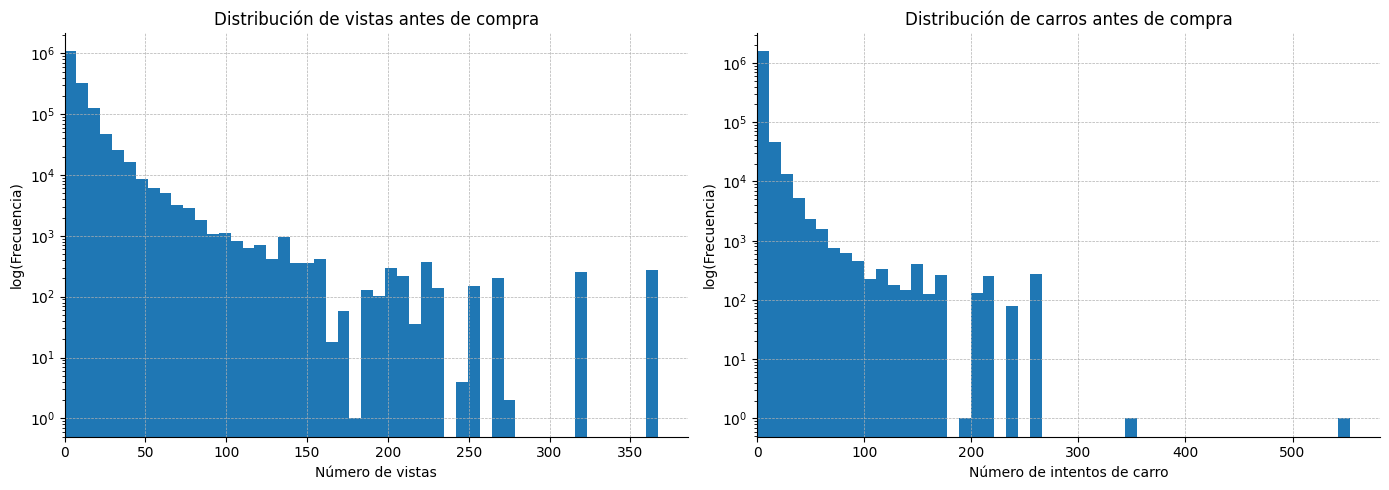

In [7]:
# ============================================
# 2. ANÁLISIS DE COMPORTAMIENTO PREVIO A COMPRA
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------
# Views
# ------------------------------------------------
axes[0].hist(df["view_count"], bins=50)

axes[0].set_yscale("log")

axes[0].set_title("Distribución de vistas antes de compra")
axes[0].set_xlabel("Número de vistas")
axes[0].set_ylabel("log(Frecuencia)")

axes[0].set_xlim(left=0)

axes[0].grid(True, linestyle="--", linewidth=0.5)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# ------------------------------------------------
# Cart
# ------------------------------------------------
axes[1].hist(df["cart_count"], bins=50)

axes[1].set_yscale("log")

axes[1].set_title("Distribución de carros antes de compra")
axes[1].set_xlabel("Número de intentos de carro")
axes[1].set_ylabel("log(Frecuencia)")

axes[1].set_xlim(left=0)

axes[1].grid(True, linestyle="--", linewidth=0.5)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# ------------------------------------------------
# Layout
# ------------------------------------------------
plt.tight_layout()

plt.show()

In [8]:
# Estadísticas de compras directas
no_view = (df["view_count"] == 0).sum()
no_cart = (df["cart_count"] == 0).sum()

print(f"\n=== COMPRAS DIRECTAS ===\n")
print(f"Compras sin vistas previas: {no_view:,}")
print(f"Compras sin carro previo: {no_cart:,}")


=== COMPRAS DIRECTAS ===

Compras sin vistas previas: 3,583
Compras sin carro previo: 455,527


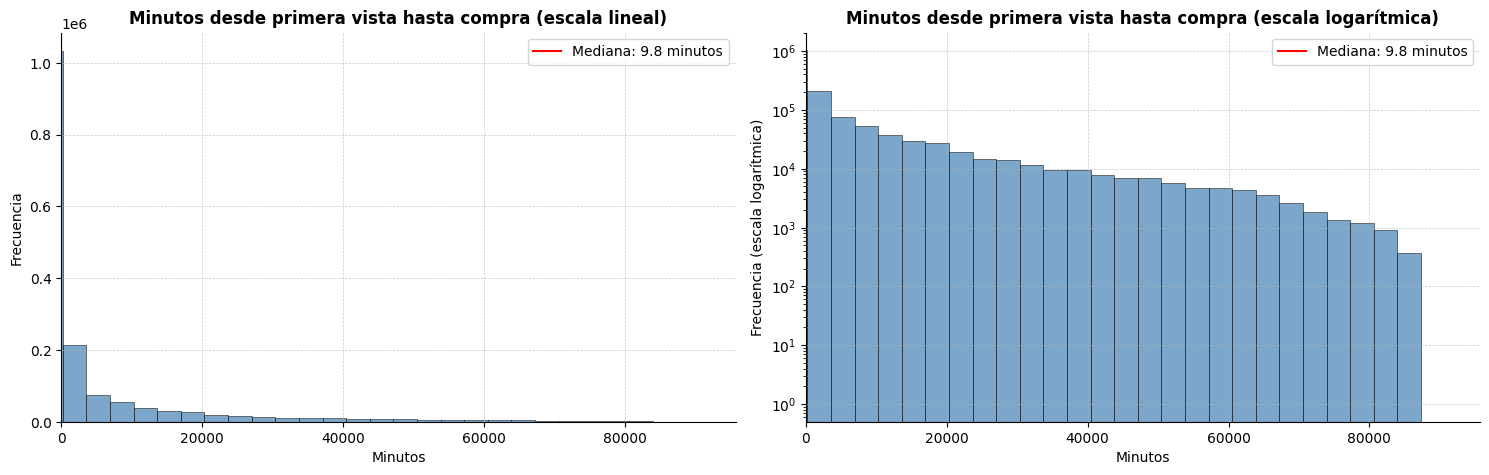


=== ESTADÍSTICAS DEL TIEMPO HASTA COMPRA (minutos) ===

Total de compras analizadas: 1,601,909
Media: 4881.79 minutos
Mediana: 9.77 minutos
Mínimo: -80163.80 minutos
Máximo: 87316.13 minutos
Percentil 95: 31581.87 minutos


In [67]:
# ============================================
# 3. ANÁLISIS TEMPORAL - TIEMPO A COMPRA
# ============================================
# Calcular tiempo desde primera vista hasta compra (en minutos)
df["time_to_purchase_view"] = (df["event_time"] - df["first_view"]).dt.total_seconds() / 60

# Obtener datos limpios
data_clean = df["time_to_purchase_view"].dropna()

# Crear figura con 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Sin escala logarítmica
n1, bins1, patches1 = ax1.hist(data_clean, bins=50, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
ax1.set_title("Minutos desde primera vista hasta compra (escala lineal)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Minutos", fontsize=10)
ax1.set_ylabel("Frecuencia", fontsize=10)
ax1.set_xlim(left=0)
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Añadir línea de mediana
median_val = data_clean.median()
ax1.axvline(median_val, color='red', linestyle='-', linewidth=1.5, label=f'Mediana: {median_val:.1f} minutos')
ax1.legend()

# Gráfico 2: Con escala logarítmica
n2, bins2, patches2 = ax2.hist(data_clean, bins=50, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5, log=True)
ax2.set_title("Minutos desde primera vista hasta compra (escala logarítmica)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Minutos", fontsize=10)
ax2.set_ylabel("Frecuencia (escala logarítmica)", fontsize=10)
ax2.set_xlim(left=0)
ax2.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Añadir línea de mediana
ax2.axvline(median_val, color='red', linestyle='-', linewidth=1.5, label=f'Mediana: {median_val:.1f} minutos')
ax2.legend()

plt.tight_layout()
plt.show()

# Imprimir estadísticas
print("\n=== ESTADÍSTICAS DEL TIEMPO HASTA COMPRA (minutos) ===\n")
print(f"Total de compras analizadas: {len(data_clean):,}")
print(f"Media: {data_clean.mean():.2f} minutos")
print(f"Mediana: {data_clean.median():.2f} minutos")
print(f"Mínimo: {data_clean.min():.2f} minutos")
print(f"Máximo: {data_clean.max():.2f} minutos")
print(f"Percentil 95: {data_clean.quantile(0.95):.2f} minutos")

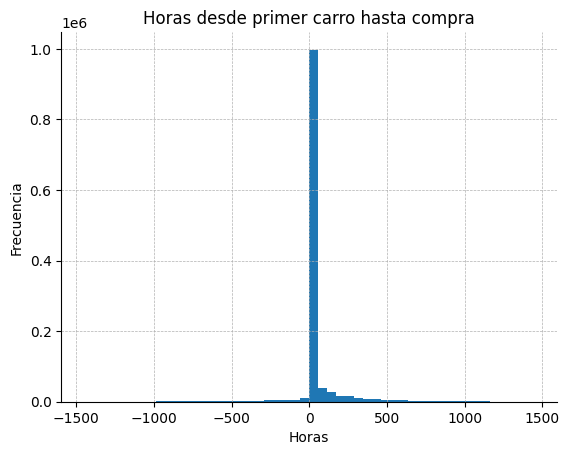

In [10]:
# Calcular tiempo desde primer carro hasta compra (en horas)
df["time_to_purchase_cart"] = (df["event_time"] - df["first_cart"]).dt.total_seconds() / 3600

# Visualización: Tiempo carro → compra
plt.figure()
plt.hist(df["time_to_purchase_cart"].dropna(), bins=50)
plt.title("Horas desde primer carro hasta compra")
plt.xlabel("Horas")
plt.ylabel("Frecuencia")

# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

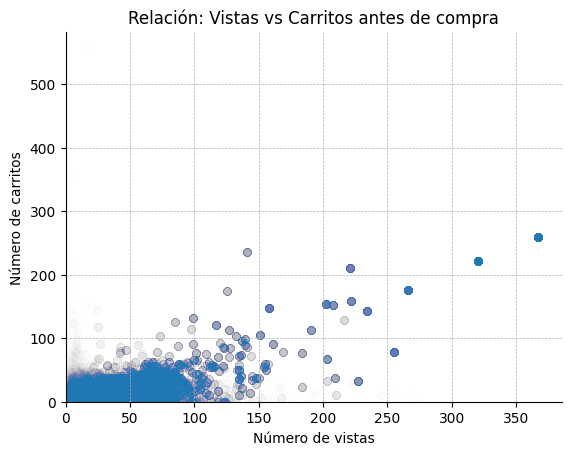

In [11]:
# Correlación: Views vs Carritos
plt.figure()
plt.scatter(df["view_count"], df["cart_count"], alpha=0.005)
plt.title("Relación: Vistas vs Carritos antes de compra")
plt.xlabel("Número de vistas")
plt.ylabel("Número de carritos")
plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

In [12]:
# ============================================
# 4. ANÁLISIS DE OUTLIERS
# ============================================
# Identificar compras con comportamiento extremo
outliers = df[df["view_count"] > 100]

print(f"\n=== ANÁLISIS DE OUTLIERS ===\n")
print(f"Número de compras con >100 vistas: {outliers.shape[0]}")
print(f"Máximo de vistas observado: {df['view_count'].max()}")
print(f"\n=== EJEMPLOS DE OUTLIERS ===\n")
print(outliers[["user_id", "product_id", "view_count"]].head())


=== ANÁLISIS DE OUTLIERS ===

Número de compras con >100 vistas: 7264
Máximo de vistas observado: 367

=== EJEMPLOS DE OUTLIERS ===

       user_id  product_id  view_count
111  543272936     1004856         133
578  512964148     1005234         132
661  538473314     1004856         148
905  543272936     1004856         133
964  513117637     1005117         137


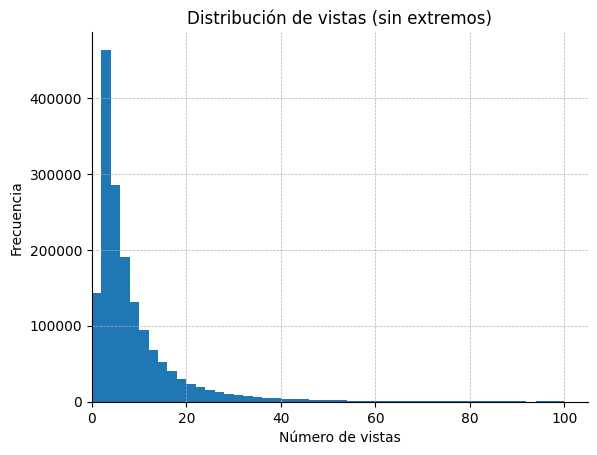

In [13]:
# Visualización: Distribución sin extremos
filtered = df[df["view_count"] <= 100]

plt.figure()
plt.hist(filtered["view_count"], bins=50)
plt.title("Distribución de vistas (sin extremos)")
plt.xlabel("Número de vistas")
plt.ylabel("Frecuencia")
plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

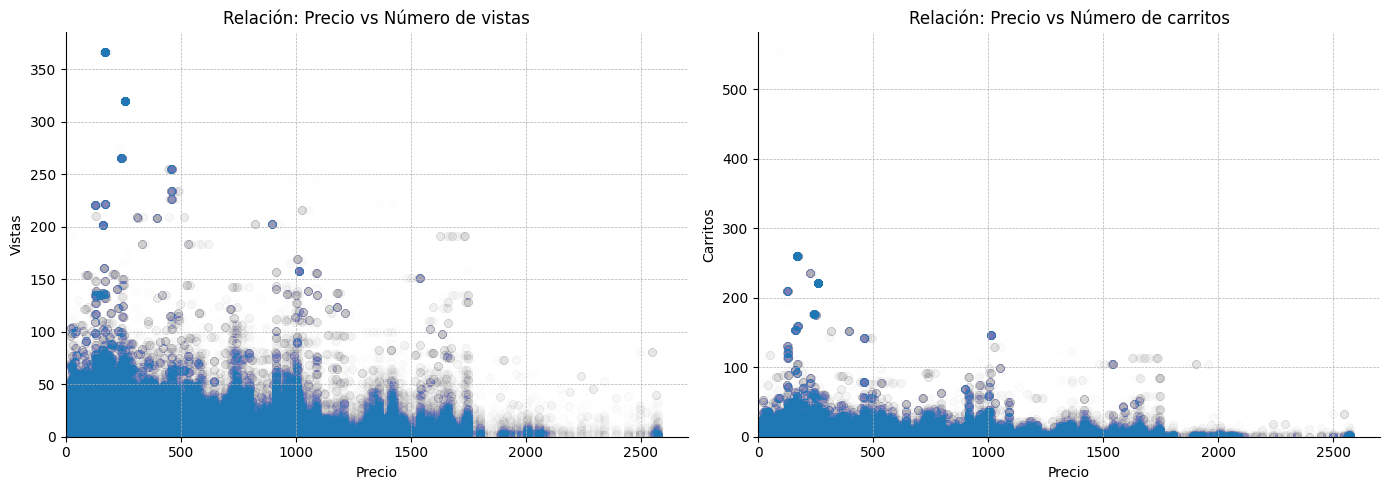

In [14]:
# ============================================
# 5. ANÁLISIS DE PRECIO
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------
# Relación: Precio vs Comportamiento de navegación
# ------------------------------------------------
axes[0].scatter(df["price"], df["view_count"], alpha=0.005)


axes[0].set_title("Relación: Precio vs Número de vistas")
axes[0].set_xlabel("Precio")
axes[0].set_ylabel("Vistas")

axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)


axes[0].grid(True, linestyle="--", linewidth=0.5)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# ------------------------------------------------
# Cart
# ------------------------------------------------
axes[1].scatter(df["price"], df["cart_count"], alpha=0.005)

axes[1].set_title("Relación: Precio vs Número de carritos")
axes[1].set_xlabel("Precio")
axes[1].set_ylabel("Carritos")

axes[1].set_xlim(left=0)
axes[1].set_ylim(bottom=0)
axes[1].grid(True, linestyle="--", linewidth=0.5)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# ------------------------------------------------
# Layout
# ------------------------------------------------
plt.tight_layout()

plt.show()

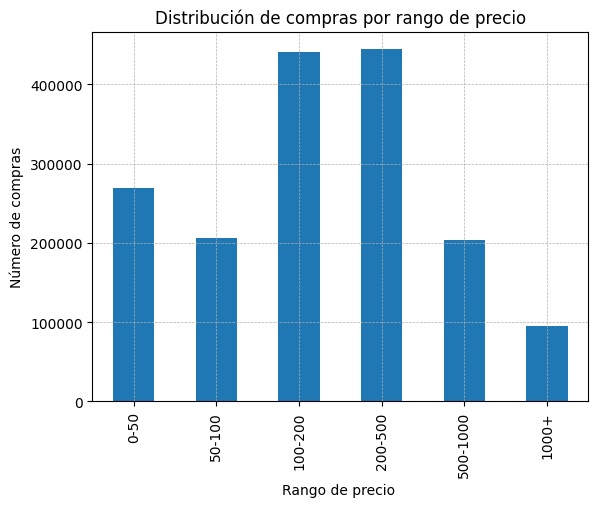

In [15]:
# ============================================
# 6. SEGMENTACIÓN POR RANGO DE PRECIO
# ============================================
# Crear rangos de precio para análisis
bins = [0, 50, 100, 200, 500, 1000, 5000]
labels = ["0-50", "50-100", "100-200", "200-500", "500-1000", "1000+"]

df["price_range"] = pd.cut(df["price"], bins=bins, labels=labels)

# Distribución de compras por rango de precio
price_dist = df["price_range"].value_counts().sort_index()

# Visualización
plt.figure()
price_dist.plot(kind="bar")
plt.title("Distribución de compras por rango de precio")
plt.xlabel("Rango de precio ")
plt.ylabel("Número de compras")


# Grid
plt.grid(True, linestyle="--", linewidth=0.5)


plt.show()

In [16]:
# Resumen de métricas clave
print(f"\n=== MÉTRICAS DE COMPORTAMIENTO PREVIO A COMPRA ===\n")
print(f"Media de vistas antes de compra: {df['view_count'].mean():.2f}")
print(f"Media de carritos antes de compra: {df['cart_count'].mean():.2f}")
print(f"\nMediana de tiempo (horas) vista → compra: {df['time_to_purchase_view'].median():.2f}")
print(f"Mediana de tiempo (horas) carro → compra: {df['time_to_purchase_cart'].median():.2f}")


=== MÉTRICAS DE COMPORTAMIENTO PREVIO A COMPRA ===

Media de vistas antes de compra: 9.14
Media de carritos antes de compra: 3.00

Mediana de tiempo (horas) vista → compra: 0.16
Mediana de tiempo (horas) carro → compra: 0.04



=== CLASIFICACIÓN DE USUARIOS ===

nuevo         402145
recurrente    295325
Name: count, dtype: int64

Proporción de usuarios recurrentes: 42.3%


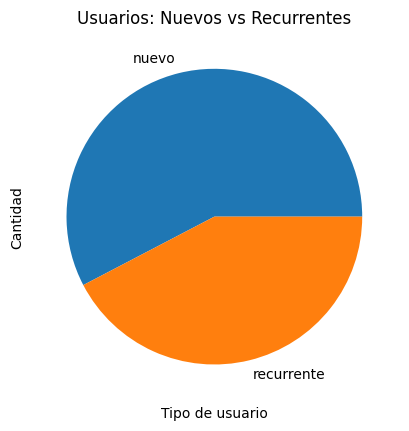

In [17]:
# ============================================
# 7. SEGMENTACIÓN DE CLIENTES
# ============================================
# Clasificar usuarios como nuevos o recurrentes
user_purchases = df.groupby("user_id").size()
user_type = user_purchases.apply(lambda x: "nuevo" if x == 1 else "recurrente")
summary = user_type.value_counts()

print(f"\n=== CLASIFICACIÓN DE USUARIOS ===\n")
print(summary)
print(f"\nProporción de usuarios recurrentes: {summary['recurrente'] / summary.sum() * 100:.1f}%")

# Visualización
plt.figure()
summary.plot(kind="pie")
plt.title("Usuarios: Nuevos vs Recurrentes")
plt.xlabel("Tipo de usuario")
plt.ylabel("Cantidad")


# Grid
plt.grid(True, linestyle="--", linewidth=0.5)


plt.show()

In [18]:
# ============================================
# 8. INGENIERÍA DE VARIABLES
# ============================================
# Recalcular/complementar variables derivadas
df["time_to_purchase_view"] = (df["event_time"] - df["first_view"]).dt.total_seconds() / 3600  # horas
df["time_to_purchase_cart"] = (df["event_time"] - df["first_cart"]).dt.total_seconds() / 3600  # horas

# Ratios de conversión
df["view_to_cart_ratio"] = df["cart_count"] / (df["view_count"] + 1)  # Evitar división por cero
df["cart_to_view_ratio"] = df["view_count"] / (df["cart_count"] + 1)

# Flags binarios
df["has_cart"] = (df["cart_count"] > 0).astype(int)  # Tuvo carrito antes
df["has_view"] = (df["view_count"] > 0).astype(int)  # Tuvo vista antes

# Características temporales
df["hour"] = df["event_time"].dt.hour  # hora del día
df["weekday"] = df["event_time"].dt.weekday  # día de la semana (0=lunes)

# Tipo de cliente
user_counts = df.groupby("user_id").size()
df["is_recurrent"] = df["user_id"].map(lambda x: 1 if user_counts[x] > 1 else 0)  # Cliente recurrente

print(f"\n=== MUESTRA DE DATASET ENRIQUECIDO ===\n")
print(df.head())


=== MUESTRA DE DATASET ENRIQUECIDO ===

           event_time    user_id  product_id   price  view_count  cart_count  \
0 2019-11-01 00:00:41  559368633    13200605  566.30           3           0   
1 2019-11-01 00:01:04  513351129     1005161  211.92           2           0   
2 2019-11-01 00:04:51  562958505     1004856  128.42          15           8   
3 2019-11-01 00:05:34  541854711    26401669  109.66           2           0   
4 2019-11-01 00:06:33  557746614     1801881  488.80          22          13   

           first_view           last_view          first_cart  \
0 2019-10-31 23:57:42 2019-11-01 00:01:20                 NaT   
1 2019-11-01 00:00:17 2019-11-01 00:01:57                 NaT   
2 2019-10-22 11:54:57 2019-11-19 08:07:51 2019-11-09 08:39:52   
3 2019-11-01 00:04:55 2019-11-01 00:06:00                 NaT   
4 2019-10-30 13:27:08 2019-11-03 12:16:38 2019-10-31 22:39:19   

            last_cart  time_to_purchase_view  time_to_purchase_cart  \
0               

Eliminamos valores inválidos:
 - Price > 0
 - Purchases que ocurren antes de la primera view

In [19]:
df = df[df["price"] > 0]
df = df[df["time_to_purchase_cart"].isna() | (df["time_to_purchase_cart"] >= 0)]

Eliminamos outliers:
 - view_count > 100
 - cart_count > 50

In [20]:
df["view_count"] = df["view_count"].clip(upper=100)
df["cart_count"] = df["cart_count"].clip(upper=50)

Creamos una flagpara los casos sin cart:

In [21]:
df["has_cart"] = (df["cart_count"] > 0).astype(int)

Añadimos otra variable util:
 - Time to purchase

In [22]:
df["time_to_purchase_view"] = (
    df["event_time"] - df["first_view"]
).dt.total_seconds() / 3600

Agregamos a nivel cliente:

In [23]:
customer_df = df.groupby("user_id").agg({
    "price": ["sum", "mean"],
    "product_id": "count",
    "view_count": "sum",
    "cart_count": "sum",
    "time_to_purchase_view": "mean",
    "time_to_purchase_cart": "mean",
    "event_time": ["min", "max"]
})

In [24]:
customer_df.columns = [
    "monetary",
    "avg_ticket",
    "frequency",
    "total_views",
    "total_carts",
    "avg_time_view",
    "avg_time_cart",
    "first_purchase",
    "last_purchase"
]

Calculamos y agregamos counts de sesiones, definiendo sesiones con boundires de 30 minutos

In [25]:
df['time_diff'] = df.groupby('user_id')['event_time'].diff()
df['new_session'] = (df['time_diff'] > pd.Timedelta(minutes=30)) | (df['time_diff'].isna())

df['session_id'] = df.groupby('user_id')['new_session'].cumsum()

session_counts = df.groupby('user_id')['session_id'].nunique().reset_index()
session_counts.columns = ['user_id', 'num_sessions']

customer_df = customer_df.merge(session_counts, on='user_id', how='left')

Crear variables RFM (fundamental para CLV)

In [26]:
snapshot_date = df["event_time"].max()

customer_df["recency"] = (
    snapshot_date - customer_df["last_purchase"]
).dt.days

customer_df["recency"].describe()

count    694608.000000
mean         24.521411
std          17.218978
min           0.000000
25%          12.000000
50%          20.000000
75%          39.000000
max          60.000000
Name: recency, dtype: float64

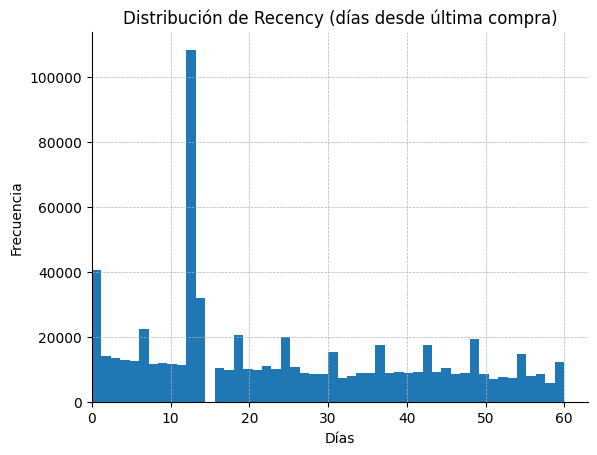

In [27]:
plt.figure()
plt.hist(customer_df["recency"].dropna(), bins=50)
plt.title("Distribución de Recency (días desde última compra)")
plt.xlabel("Días")
plt.ylabel("Frecuencia")

plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

Variables derivadas de customer

In [28]:
customer_df["conversion_rate"] = (
    customer_df["frequency"] / (customer_df["total_views"] + 1)
)

customer_df["conversion_rate"].describe()

count    694608.000000
mean          0.229081
std           0.140247
min           0.009901
25%           0.120000
50%           0.200000
75%           0.333333
max           3.000000
Name: conversion_rate, dtype: float64

In [29]:
customer_df["cart_rate"] = (
    customer_df["total_carts"] / (customer_df["total_views"] + 1)
)

customer_df["cart_rate"].describe()

count    694608.000000
mean          0.281678
std           0.353642
min           0.000000
25%           0.030303
50%           0.250000
75%           0.400000
max          48.000000
Name: cart_rate, dtype: float64

In [30]:
customer_df["is_recurrent"] = (customer_df["frequency"] > 1).astype(int)

customer_df["is_recurrent"].describe()

count    694608.000000
mean          0.416814
std           0.493032
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: is_recurrent, dtype: float64

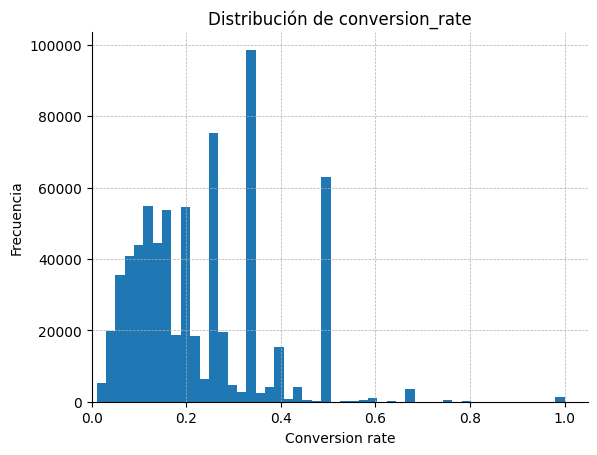

In [31]:
filtered = customer_df[customer_df["conversion_rate"] <= 1]

plt.figure()
plt.hist(filtered["conversion_rate"].dropna(), bins=50)
plt.title("Distribución de conversion_rate")
plt.xlabel("Conversion rate")
plt.ylabel("Frecuencia")

plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()


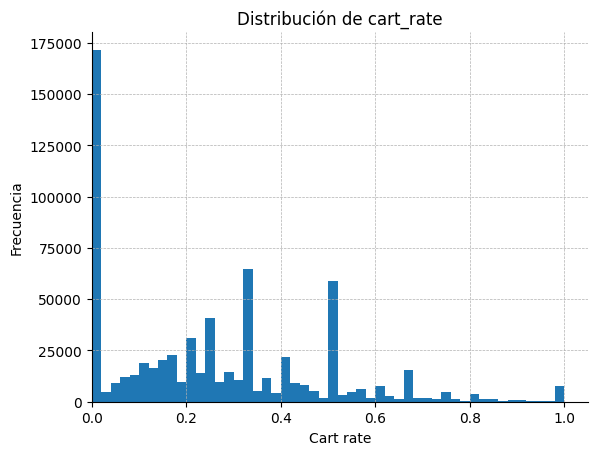

In [32]:
filtered = customer_df[customer_df["cart_rate"] <= 1]

plt.figure()
plt.hist(filtered["cart_rate"].dropna(), bins=50)
plt.title("Distribución de cart_rate")
plt.xlabel("Cart rate")
plt.ylabel("Frecuencia")

plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

Definimos el CLV 

In [33]:
customer_df["CLV"] = (
    customer_df["avg_ticket"] * customer_df["frequency"]
)

customer_df["CLV"].describe()

count    694608.000000
mean        696.942273
std        2105.961905
min           0.770000
25%         117.090000
50%         256.550000
75%         656.035000
max      301617.620000
Name: CLV, dtype: float64

Intensidad de interacción

In [34]:
customer_df["views_per_purchase"] = (
    customer_df["total_views"] / (customer_df["frequency"] + 1)
)

customer_df["views_per_purchase"].describe()

count    694608.000000
mean          3.840415
std           4.313670
min           0.000000
25%           1.500000
50%           2.500000
75%           4.700000
max          99.459459
Name: views_per_purchase, dtype: float64

In [35]:
customer_df["carts_per_purchase"] = (
    customer_df["total_carts"] / (customer_df["frequency"] + 1)
)

customer_df["carts_per_purchase"].describe()

count    694608.000000
mean          1.032373
std           1.686275
min           0.000000
25%           0.200000
50%           0.500000
75%           1.250000
max          49.729730
Name: carts_per_purchase, dtype: float64

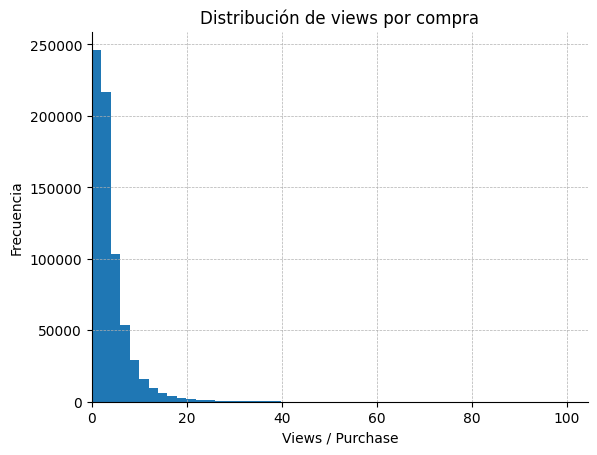

In [36]:
filtered = customer_df[customer_df["views_per_purchase"] <= 100]

plt.figure()
plt.hist(filtered["views_per_purchase"].dropna(), bins=50)
plt.title("Distribución de views por compra")
plt.xlabel("Views / Purchase")
plt.ylabel("Frecuencia")

plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

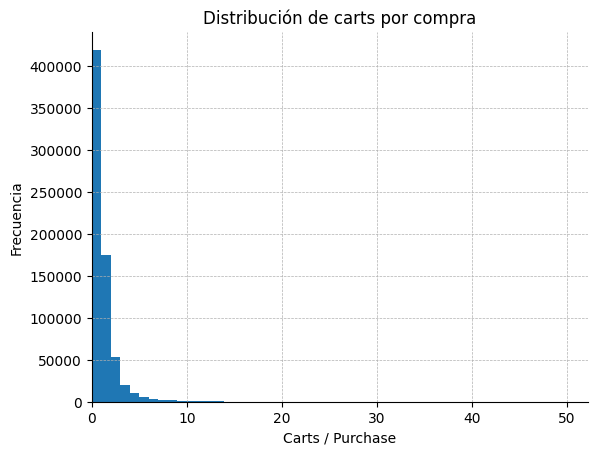

In [37]:
filtered = customer_df[customer_df["carts_per_purchase"] <= 50]

plt.figure()
plt.hist(filtered["carts_per_purchase"].dropna(), bins=50)
plt.title("Distribución de carts por compra")
plt.xlabel("Carts / Purchase")
plt.ylabel("Frecuencia")

plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

Conversiónes:

In [38]:
customer_df["view_to_purchase"] = (
    customer_df["frequency"] / (customer_df["total_views"] + 1)
)

customer_df["view_to_purchase"].describe()

count    694608.000000
mean          0.229081
std           0.140247
min           0.009901
25%           0.120000
50%           0.200000
75%           0.333333
max           3.000000
Name: view_to_purchase, dtype: float64

In [39]:
customer_df["cart_to_purchase"] = (
    customer_df["frequency"] / (customer_df["total_carts"] + 1)
)

customer_df["cart_to_purchase"].describe()

count    694608.000000
mean          0.727909
std           0.739155
min           0.019608
25%           0.333333
50%           0.500000
75%           1.000000
max          44.000000
Name: cart_to_purchase, dtype: float64

In [40]:
customer_df["view_to_cart"] = (
    customer_df["total_carts"] / (customer_df["total_views"] + 1)
)

customer_df["view_to_cart"].describe()

count    694608.000000
mean          0.281678
std           0.353642
min           0.000000
25%           0.030303
50%           0.250000
75%           0.400000
max          48.000000
Name: view_to_cart, dtype: float64

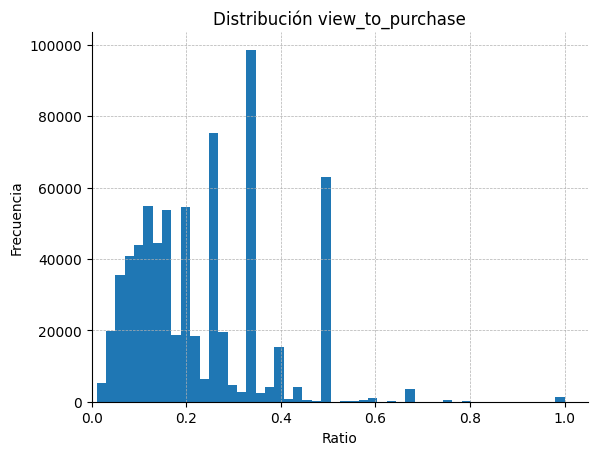

In [41]:
filtered = customer_df[customer_df["view_to_purchase"] <= 1]

plt.figure()
plt.hist(filtered["view_to_purchase"].dropna(), bins=50)
plt.title("Distribución view_to_purchase")
plt.xlabel("Ratio")
plt.ylabel("Frecuencia")

plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()


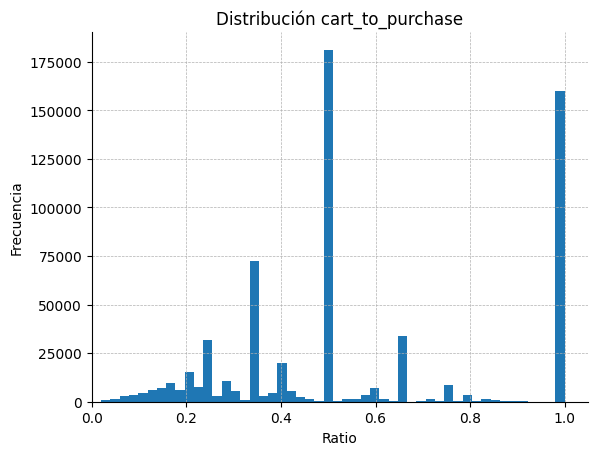

In [42]:
filtered = customer_df[customer_df["cart_to_purchase"] <= 1]

plt.figure()
plt.hist(filtered["cart_to_purchase"].dropna(), bins=50)
plt.title("Distribución cart_to_purchase")
plt.xlabel("Ratio")
plt.ylabel("Frecuencia")

plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()


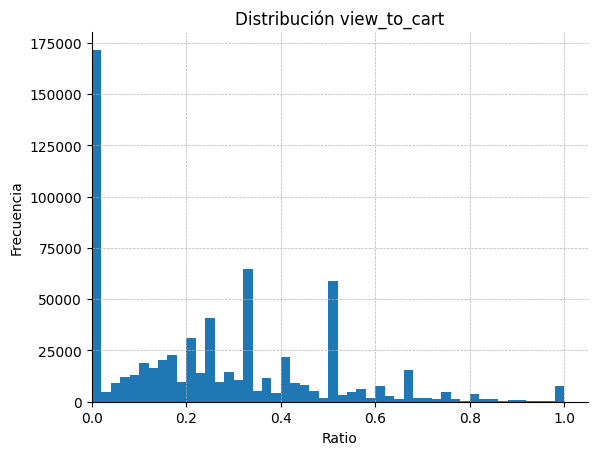

In [43]:
filtered = customer_df[customer_df["view_to_cart"] <= 1]

plt.figure()
plt.hist(filtered["view_to_cart"].dropna(), bins=50)
plt.title("Distribución view_to_cart")
plt.xlabel("Ratio")
plt.ylabel("Frecuencia")

plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

Engagement

In [44]:
customer_df["events_per_session"] = (
    (customer_df["total_views"] + customer_df["total_carts"]) /
    (customer_df["num_sessions"] + 1)
)

customer_df["events_per_session"].describe()

count    694608.000000
mean          6.364287
std          10.566162
min           0.000000
25%           2.000000
50%           3.750000
75%           7.333333
max        1322.705882
Name: events_per_session, dtype: float64

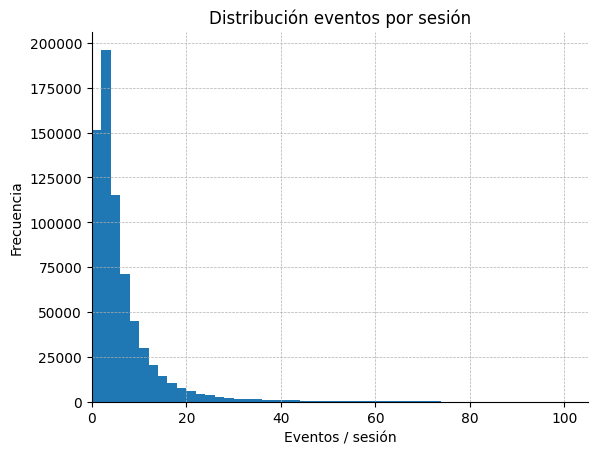

In [45]:
filtered = customer_df[customer_df["events_per_session"] <= 100]

plt.figure()
plt.hist(filtered["events_per_session"].dropna(), bins=50)
plt.title("Distribución eventos por sesión")
plt.xlabel("Eventos / sesión")
plt.ylabel("Frecuencia")

plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

Antigüedad del cliente

In [46]:
customer_df["customer_lifetime"] = (
    customer_df["last_purchase"] - customer_df["first_purchase"]
).dt.days

customer_df["customer_lifetime"].describe()

count    694608.000000
mean          5.382830
std          11.986752
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          60.000000
Name: customer_lifetime, dtype: float64

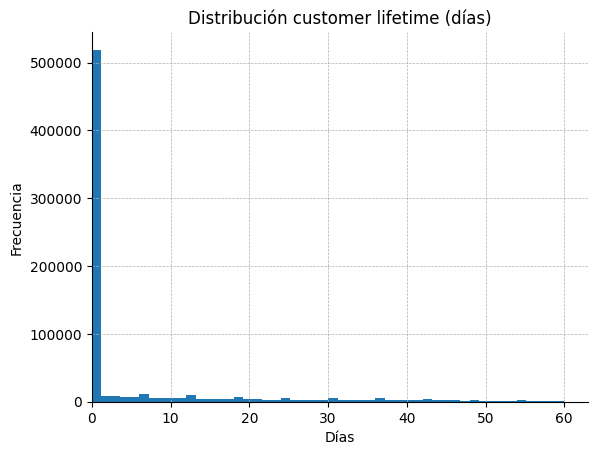

In [47]:
plt.figure()
plt.hist(customer_df["customer_lifetime"].dropna(), bins=50)
plt.title("Distribución customer lifetime (días)")
plt.xlabel("Días")
plt.ylabel("Frecuencia")

plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

Tiempo medio entre compras

In [48]:
customer_df["avg_time_between_purchases"] = (
    customer_df["customer_lifetime"] / (customer_df["frequency"] + 1)
)

customer_df["avg_time_between_purchases"].describe()

count    694608.000000
mean          1.129175
std           2.642311
min           0.000000
25%           0.000000
50%           0.000000
75%           0.333333
max          20.000000
Name: avg_time_between_purchases, dtype: float64

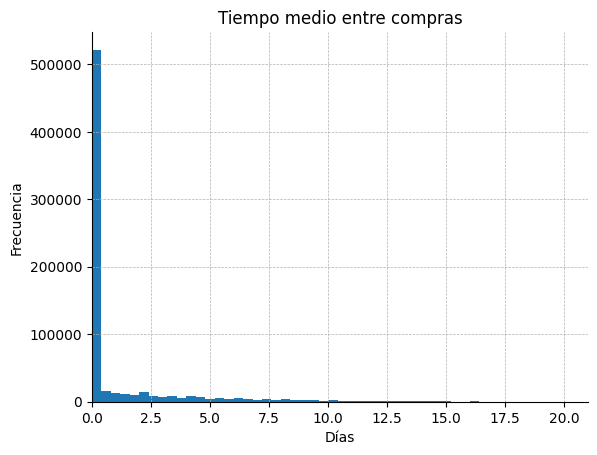

In [49]:
filtered = customer_df[customer_df["avg_time_between_purchases"] <= 365]

plt.figure()
plt.hist(filtered["avg_time_between_purchases"].dropna(), bins=50, )
plt.title("Tiempo medio entre compras")
plt.xlabel("Días")
plt.ylabel("Frecuencia")

plt.xlim(0)
plt.ylim(0)
# Grid
plt.grid(True, linestyle="--", linewidth=0.5)

# Quitar spines superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

Segmentación por gasto

In [50]:
customer_df["high_value_customer"] = (
    customer_df["monetary"] > customer_df["monetary"].quantile(0.75)
).astype(int)

customer_df["high_value_customer"].describe()

count    694608.000000
mean          0.250000
std           0.433013
min           0.000000
25%           0.000000
50%           0.000000
75%           0.250000
max           1.000000
Name: high_value_customer, dtype: float64

Usuarios intensivos

In [51]:
customer_df["heavy_viewer"] = (
    customer_df["total_views"] > customer_df["total_views"].quantile(0.9)
).astype(int)

customer_df["heavy_viewer"].describe()

count    694608.000000
mean          0.099273
std           0.299029
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: heavy_viewer, dtype: float64

Validación de features

In [52]:
customer_df.corr()["CLV"].sort_values(ascending=False)

monetary                      1.000000
CLV                           1.000000
frequency                     0.749509
num_sessions                  0.680617
total_views                   0.631937
total_carts                   0.572372
events_per_session            0.472692
high_value_customer           0.395444
carts_per_purchase            0.358855
avg_ticket                    0.342636
heavy_viewer                  0.341340
views_per_purchase            0.326719
customer_lifetime             0.302748
is_recurrent                  0.241021
avg_time_cart                 0.195322
avg_time_view                 0.107630
last_purchase                 0.101008
avg_time_between_purchases    0.090364
cart_rate                     0.054484
view_to_cart                  0.054484
cart_to_purchase              0.002695
user_id                      -0.019275
view_to_purchase             -0.080500
conversion_rate              -0.080500
recency                      -0.100836
first_purchase           

Validamos Nulls

In [53]:
customer_df.isnull().sum()

user_id                            0
monetary                           0
avg_ticket                         0
frequency                          0
total_views                        0
total_carts                        0
avg_time_view                   1208
avg_time_cart                 170451
first_purchase                     0
last_purchase                      0
num_sessions                       0
recency                            0
conversion_rate                    0
cart_rate                          0
is_recurrent                       0
CLV                                0
views_per_purchase                 0
carts_per_purchase                 0
view_to_purchase                   0
cart_to_purchase                   0
view_to_cart                       0
events_per_session                 0
customer_lifetime                  0
avg_time_between_purchases         0
high_value_customer                0
heavy_viewer                       0
dtype: int64

In [54]:
customer_df.describe()

,user_id,monetary,avg_ticket,frequency,total_views,total_carts,avg_time_view,avg_time_cart,first_purchase,last_purchase,...,views_per_purchase,carts_per_purchase,view_to_purchase,cart_to_purchase,view_to_cart,events_per_session,customer_lifetime,avg_time_between_purchases,high_value_customer,heavy_viewer
count,6.946080e+05,694608.000000,694608.000000,694608.00000,694608.000000,694608.000000,693400.000000,524157.000000,694608,694608,...,694608.000000,694608.000000,694608.000000,694608.000000,694608.000000,694608.000000,694608.000000,694608.000000,694608.000000,694608.000000
mean,5.401835e+08,696.942273,276.745695,2.31135,19.884379,6.390363,53.427174,17.691024,2019-10-31 09:32:13.934219008,2019-11-05 22:25:59.526109952,...,3.840415,1.032373,0.229081,0.727909,0.281678,6.364287,5.382830,1.129175,0.250000,0.099273
min,1.383403e+08,0.770000,0.770000,1.00000,0.000000,0.000000,-481.127222,0.001667,2019-10-01 00:04:37,2019-10-01 00:06:02,...,0.000000,0.000000,0.009901,0.019608,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.183917e+08,117.090000,86.200000,1.00000,3.000000,1.000000,0.057778,0.027222,2019-10-15 04:47:29.249999872,2019-10-22 07:31:10.750000128,...,1.500000,0.200000,0.120000,0.333333,0.030303,2.000000,0.000000,0.000000,0.000000,0.000000
50%,5.401683e+08,256.550000,171.690000,1.00000,6.000000,1.000000,0.234167,0.056667,2019-11-01 10:46:55,2019-11-10 11:15:58.500000,...,2.500000,0.500000,0.200000,0.500000,0.250000,3.750000,0.000000,0.000000,0.000000,0.000000
75%,5.597632e+08,656.035000,332.943125,2.00000,15.000000,4.000000,29.357431,0.425648,2019-11-17 07:09:09,2019-11-18 04:17:13,...,4.700000,1.250000,0.333333,1.000000,0.400000,7.333333,2.000000,0.333333,0.250000,0.000000
max,5.799671e+08,301617.620000,2574.070000,622.00000,49377.000000,24846.000000,1451.961481,1411.690833,2019-11-30 23:58:22,2019-11-30 23:59:44,...,99.459459,49.729730,3.000000,44.000000,48.000000,1322.705882,60.000000,20.000000,1.000000,1.000000
std,2.144586e+07,2105.961905,304.281190,4.13248,160.551673,74.450593,138.280100,66.192633,NaN,NaN,...,4.313670,1.686275,0.140247,0.739155,0.353642,10.566162,11.986752,2.642311,0.433013,0.299029


In [55]:
customer_df.to_csv("./data/customer_clv.csv", index=False)

In [56]:
df.to_csv("./data/purchases_enriched.csv", index=False)